<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/graph2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph 2
Graph with multiple sequential nodes and multiple inputs

In [2]:
!pip install langgraph --quiet

In [6]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

State with 3 attributes

In [8]:
class State[TypedDict]:
  nums: List[int]
  name: str
  result: int

two functions for two nodes.

In [32]:
def greeting(state: State) -> State:
  """Function to build a greeting from the name."""
  state["result"] = f"Hi {state["name"]}, the result is: "
  return state

def add_nums(state: State) -> State:
  """Function to add the numbers."""
  state["result"] += str(sum(state["nums"]))
  return state

build the graph

In [29]:
graph = StateGraph(state)
graph.add_node("greet", greeting)
graph.add_node("adder", add_nums)
graph.add_edge(START, "greet")
graph.add_edge("greet", "adder")
graph.add_edge("adder", END)
app = graph.compile()

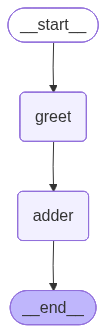

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

Test it

In [31]:
result = app.invoke({"name": "Tim", "nums": [3, 4, 5]})
print(result)

{'nums': [3, 4, 5], 'name': 'Tim', 'result': 'Hi Tim, the result is: 12'}
